# Spike Analysis Tutorial

This tutorial covers frequency-domain spike detection and integrating the results with
continuous EEG features in NeuRodent.

## Overview

NeuRodent detects population spikes directly from the recording using a frequency-domain
detector (STFT + smoothed nonlinear energy operator), rather than by spike-sorting single
units. The result is a `FrequencyDomainSpikeAnalysisResult` (FDSAR) per recording session:

1. Run frequency-domain spike detection over a recording
2. Inspect per-channel spike counts
3. Convert to MNE format and save/load results
4. Analyze the EEG around detected spike times
5. Fold spike counts back into a `WindowAnalysisResult` for combined analysis

This mirrors what the Snakemake pipeline does in `workflow/scripts/generate_wars.py`, in a
simplified form. It runs on the example recordings bundled with the package.

In [1]:
import logging
import tempfile
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from neurodent import (
    AnimalOrganizer,
    AnimalAnalyzer,
    AnimalPlotter,
    FrequencyDomainSpikeAnalysisResult,
    constants,
    set_channel_map,
)

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

/home/runner/work/neurodent/neurodent/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Loading the Recording

Spike detection runs on the same `AnimalOrganizer` used for windowed analysis, so the setup
is identical: declare the channel map and per-animal metadata, then point at the data.

In [2]:
from neurodent.data import sample_dataset

SAMPLE_DATA = sample_dataset()

### Using your own data

Replace `SAMPLE_DATA` with your own directory and set `extract_func` for your format.
[Data Loading](../quickstart/data_loading.ipynb) covers readers and patterns.


In [3]:
set_channel_map({
    "LMot": ["C-015", "D-015"],
    "RMot": ["C-016", "D-016"],
    "LBar": ["C-014", "D-014"],
    "RBar": ["C-017", "D-017"],
    "LHip": ["C-012", "D-012"],
    "RHip": ["C-019", "D-019"],
    "LAud": ["C-009", "D-009"],
    "RAud": ["C-022", "D-022"],
    "LVis": ["C-010", "D-010"],
    "RVis": ["C-021", "D-021"],
})

constants.ANIMAL_METADATA = {
    "A10": {"genotype": "WT", "sex": "Male"},
    "F22": {"genotype": "KO", "sex": "Female"},
}

animal_id = "F22"

ao = AnimalOrganizer(
    pattern=[
        str(SAMPLE_DATA / "{animal}" / "*_ColMajor.bin"),
        str(SAMPLE_DATA / "{animal}" / "*_Meta.csv"),
    ],
    animal_id=animal_id,
    lro_kwargs={
        "mode": "si",
        "extract_func": "neurodent.readers:read_bin_csv_pair",
        "manual_datetimes": datetime(2023, 12, 12, 2, 0),
    },
)

analyzer = AnimalAnalyzer(ao)
analyzer.compute_bad_channels()

INFO:root:Processing manual_datetimes configuration
INFO:root:Processing global manual datetimes starting at 2023-12-12 02:00:00
INFO:root:Computing continuous timeline for 1 animaldays (1 total items) starting at 2023-12-12 02:00:00
INFO:root:Ordered items for timeline: ['Cage 3 F22-0_ColMajor.bin...']
INFO:root:Recording already at target sampling rate (1000 Hz) or unable to determine, no resampling needed
INFO:root:Finalizing file timestamps
INFO:root:Using manual timestamps: 1 file end times specified
INFO:root:Item Cage 3 F22-0_ColMajor.bin...: duration = 60.0s (loaded with manual timestamp)
INFO:root:Timeline computed: 1 items, total duration 60.0s
INFO:root:Recording already at target sampling rate (1000 Hz) or unable to determine, no resampling needed
INFO:root:Finalizing file timestamps
INFO:root:Using manual timestamps: 1 file end times specified
INFO:root:AnimalOrganizer Timeline Summary:
LRO 0: 2023-12-12 02:00:00 -> 2023-12-12 02:01:00 (duration: 60.0s, items: 1, item: Cag

INFO:root:Processing global manual datetimes starting at 2023-12-12 02:00:00


INFO:root:Computing continuous timeline for 1 animaldays (1 total items) starting at 2023-12-12 02:00:00


INFO:root:Ordered items for timeline: ['Cage 3 F22-0_ColMajor.bin...']


INFO:root:Recording already at target sampling rate (1000 Hz) or unable to determine, no resampling needed


...

INFO:root:AnimalOrganizer Timeline Summary:
LRO 0: 2023-12-12 02:00:00 -> 2023-12-12 02:01:00 (duration: 60.0s, items: 1, item: Cage 3 F22-0_ColMajor.bin...)


INFO:root:Computing bad channels for 1 recordings with threshold=None


INFO:root:Computed n_neighbors for LOF computation: 2


INFO:root:LOF computation successful: 10 channels


INFO:root:Computed LOF scores for 10 channels


## 2. Frequency Domain Spike Detection

`compute_frequency_domain_spike_analysis` runs the detector over every valid recording and
returns one FDSAR per session. Passing `detection_params=None` uses
`FrequencyDomainSpikeDetector.DEFAULT_PARAMS`; pass a dict to override individual values
(bandpass, SNEO threshold percentile, clustering gap, and so on).

In [4]:
# Compute frequency domain spike analysis
fdsars = analyzer.compute_frequency_domain_spike_analysis(
    detection_params=None,       # use FrequencyDomainSpikeDetector.DEFAULT_PARAMS
    multiprocess_mode='serial',
)

print(f"Found {len(fdsars)} session(s)")
for fdsar in fdsars:
    print(f"  {fdsar.animal_id} ({fdsar.genotype}): "
          f"{fdsar.get_total_spike_count()} spikes over {len(fdsar.channel_names)} channels")

INFO:root:Running frequency-domain spike detection on 1 recordings
INFO:root:Detection parameters: None
INFO:root:Detecting spikes with parameters: {'bp': [3.0, 40.0], 'notch': 60.0, 'notch_q': 30.0, 'freq_slices': [10.0, 20.0], 'window_s': 0.125, 'sneo_percentile': 99.99, 'cluster_gap_ms': 80.0, 'search_ms': 160.0, 'baseline_ms': 500.0, 'k_sigma': 3.0, 'smooth_window': 7, 'vote_k': 2, 'smooth_len': 5}
INFO:root:Step 2/4: SNEO detection found 1 candidate spikes
INFO:root:Step 3/4: After refinement and validation: 0 spikes retained
INFO:root:Step 4/4: Final spike count after clustering: 0 spikes
INFO:root:Step 2/4: SNEO detection found 0 candidate spikes
INFO:root:Step 3/4: After refinement and validation: 0 spikes retained
INFO:root:Step 4/4: Final spike count after clustering: 0 spikes
INFO:root:Step 2/4: SNEO detection found 1 candidate spikes
INFO:root:Step 3/4: After refinement and validation: 0 spikes retained
INFO:root:Step 4/4: Final spike count after clustering: 0 spikes
INFO:r

INFO:root:Detection parameters: None


INFO:root:Detecting spikes with parameters: {'bp': [3.0, 40.0], 'notch': 60.0, 'notch_q': 30.0, 'freq_slices': [10.0, 20.0], 'window_s': 0.125, 'sneo_percentile': 99.99, 'cluster_gap_ms': 80.0, 'search_ms': 160.0, 'baseline_ms': 500.0, 'k_sigma': 3.0, 'smooth_window': 7, 'vote_k': 2, 'smooth_len': 5}


INFO:root:Step 2/4: SNEO detection found 1 candidate spikes


INFO:root:Step 3/4: After refinement and validation: 0 spikes retained


...

INFO:root:Channel abbreviations: 	['LAud', 'LVis', 'LHip', 'LBar', 'LMot', 'RMot', 'RBar', 'RHip', 'RVis', 'RAud']


INFO:root:Detection parameters: 	{}


INFO:root:Recording 1/1: Detected 7 spikes across 10 channels


INFO:root:Completed frequency-domain spike detection. Total recordings processed: 1


Found 1 session(s)
  F22 (KO): 7 spikes over 10 channels


## 3. Working with Spike Analysis Results

Access spike-related features:

In [5]:
# Get spike counts per channel
for fdsar in fdsars:
    counts = fdsar.get_spike_counts_per_channel()
    total = fdsar.get_total_spike_count()
    print(f"Session {fdsar.animal_id}: {total} total spikes")
    for ch_name, count in zip(fdsar.channel_abbrevs, counts):
        print(f"  {ch_name}: {count} spikes")

Session F22: 7 total spikes
  LAud: 0 spikes
  LVis: 0 spikes
  LHip: 0 spikes
  LBar: 1 spikes
  LMot: 1 spikes
  RMot: 0 spikes
  RBar: 2 spikes
  RHip: 0 spikes
  RVis: 2 spikes
  RAud: 1 spikes


## 4. Converting to MNE Format

An FDSAR can be converted to an MNE `RawArray` with the detected spikes attached as annotations (`Spike_Ch0`, `Spike_Ch1`, …), which opens up MNE's epoching and time-frequency tooling. `save_fif_and_json` writes that raw object plus the detection metadata.

In [6]:
# Use a temporary directory so this tutorial does not write into the docs source tree.
output_root = Path(tempfile.mkdtemp())

for fdsar in fdsars:
    # Convert to an MNE Raw object with spikes as annotations
    fdsar.convert_to_mne(chunk_duration_s=60)  # seconds

    # `path_safe_save_stem` slugifies animal id / genotype / day into a safe folder name
    output_path = output_root / fdsar.path_safe_save_stem
    fdsar.save_fif_and_json(output_path, overwrite=True)
    print(f"Wrote {output_path}")

Creating RawArray with float64 data, n_channels=10, n_times=60000
    Range : 0 ... 59999 =      0.000 ...    59.999 secs
Ready.
Writing /tmp/tmp4plymbhh/f22-ko-f22_unknown/f22-ko-f22_unknown-raw.fif
Closing /tmp/tmp4plymbhh/f22-ko-f22_unknown/f22-ko-f22_unknown-raw.fif
[done]
Wrote /tmp/tmp4plymbhh/f22-ko-f22_unknown


    Range : 0 ... 59999 =      0.000 ...    59.999 secs


Ready.


Writing /tmp/tmp4plymbhh/f22-ko-f22_unknown/f22-ko-f22_unknown-raw.fif


Closing /tmp/tmp4plymbhh/f22-ko-f22_unknown/f22-ko-f22_unknown-raw.fif


[done]


INFO:root:Saved FrequencyDomainSpikeAnalysisResult to /tmp/tmp4plymbhh/f22-ko-f22_unknown


Wrote /tmp/tmp4plymbhh/f22-ko-f22_unknown


## 5. Loading Saved Results

Load previously saved spike analysis results:

In [7]:
# Load FDSAR back from the saved files
sar_path = output_root / fdsars[0].path_safe_save_stem
fdsar_loaded = FrequencyDomainSpikeAnalysisResult.load_fif_and_json(sar_path)

# Access the MNE raw object
raw = fdsar_loaded.result_mne
print(f"Loaded {raw.info['nchan']} channels, "
      f"{raw.n_times / raw.info['sfreq']:.1f}s duration, "
      f"{fdsar_loaded.get_total_spike_count()} spikes")

Opening raw data file /tmp/tmp4plymbhh/f22-ko-f22_unknown/f22-ko-f22_unknown-raw.fif...
Isotrak not found
    Range : 0 ... 59999 =      0.000 ...    59.999 secs
Ready.
Used Annotations descriptions: [np.str_('Spike_Ch3'), np.str_('Spike_Ch4'), np.str_('Spike_Ch6'), np.str_('Spike_Ch8'), np.str_('Spike_Ch9')]
Loaded 10 channels, 60.0s duration, 7 spikes


Isotrak not found


    Range : 0 ... 59999 =      0.000 ...    59.999 secs


Ready.


Used Annotations descriptions: [np.str_('Spike_Ch3'), np.str_('Spike_Ch4'), np.str_('Spike_Ch6'), np.str_('Spike_Ch8'), np.str_('Spike_Ch9')]


INFO:root:Channel names: 	['D-009', 'D-010', 'D-012', 'D-014', 'D-015', 'D-016', 'D-017', 'D-019', 'D-021', 'D-022']
INFO:root:Channel abbreviations: 	['LAud', 'LVis', 'LHip', 'LBar', 'LMot', 'RMot', 'RBar', 'RHip', 'RVis', 'RAud']
INFO:root:Detection parameters: 	{}


INFO:root:Channel abbreviations: 	['LAud', 'LVis', 'LHip', 'LBar', 'LMot', 'RMot', 'RBar', 'RHip', 'RVis', 'RAud']


INFO:root:Detection parameters: 	{}


Loaded 10 channels, 60.0s duration, 7 spikes


## 6. Peri-Event Analysis with MNE

Analyze EEG around spike times:

In [8]:
import mne

# Extract events from annotations (spike times)
events, event_dict = mne.events_from_annotations(raw)

print(f"Found {len(events)} events")
print(f"Event types: {list(event_dict.keys())}")

# Create epochs around spike times.
# A population spike is often detected on several channels at the same sample, so the same
# event time appears under more than one Spike_Ch* label. `event_repeated='merge'` collapses
# those into a single epoch instead of raising.
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_dict,
    tmin=-0.5,  # 500 ms before spike
    tmax=1.0,   # 1 s after spike
    baseline=(-0.5, -0.1),
    event_repeated='merge',
    preload=True
)

print(f"Created {len(epochs)} epochs")

Used Annotations descriptions: [np.str_('Spike_Ch3'), np.str_('Spike_Ch4'), np.str_('Spike_Ch6'), np.str_('Spike_Ch8'), np.str_('Spike_Ch9')]
Found 7 events
Event types: [np.str_('Spike_Ch3'), np.str_('Spike_Ch4'), np.str_('Spike_Ch6'), np.str_('Spike_Ch8'), np.str_('Spike_Ch9')]
Not setting metadata
7 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Loading data for 7 events and 1501 original time points ...
0 bad epochs dropped
Created 7 epochs


Found 7 events
Event types: [np.str_('Spike_Ch3'), np.str_('Spike_Ch4'), np.str_('Spike_Ch6'), np.str_('Spike_Ch8'), np.str_('Spike_Ch9')]
Not setting metadata


7 matching events found


Applying baseline correction (mode: mean)


0 projection items activated


Loading data for 7 events and 1501 original time points ...


0 bad epochs dropped


Created 7 epochs


## 7. Spike-Triggered Averages

NeuRodent ships a built-in diagnostic that averages the raw trace around every spike on a
channel, which is what the pipeline's FDSAR diagnostics step produces. Passing
`save_dir=None` displays the figures inline instead of writing them to disk.

The example recording only yields a handful of spikes per channel, so these averages are
noisy. On a full recording each would be built from far more events.

Used Annotations descriptions: [np.str_('Spike_Ch3'), np.str_('Spike_Ch4'), np.str_('Spike_Ch6'), np.str_('Spike_Ch8'), np.str_('Spike_Ch9')]
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Loading data for 1 events and 1001 original time points ...
0 bad epochs dropped
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Loading data for 1 events and 1001 original time points ...
0 bad epochs dropped
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"
Not setting metadata
2 matching events found
No baseline correction applied
0 projection items activated
Loading data for 2 events and 1001 original time points ...
0 bad epochs dropped
Not setting metadata
2 mat

Not setting metadata


1 matching events found


No baseline correction applied


0 projection items activated


...

1 matching events found


No baseline correction applied


0 projection items activated


combining channels using "mean"


/home/runner/work/neurodent/neurodent/src/neurodent/results/frequency_domain_results.py:501: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  fig = epochs.plot_image(


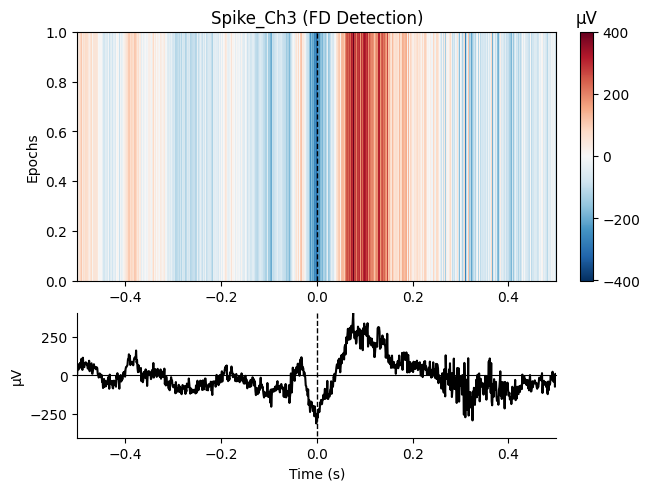

Not setting metadata


1 matching events found


No baseline correction applied


0 projection items activated


Loading data for 1 events and 1001 original time points ...


...

1 matching events found


No baseline correction applied


0 projection items activated


combining channels using "mean"


/home/runner/work/neurodent/neurodent/src/neurodent/results/frequency_domain_results.py:501: RuntimeWarning: Only one channel in group "eeg"; cannot combine by method "mean".
  fig = epochs.plot_image(
/home/runner/work/neurodent/neurodent/src/neurodent/results/frequency_domain_results.py:501: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  fig = epochs.plot_image(


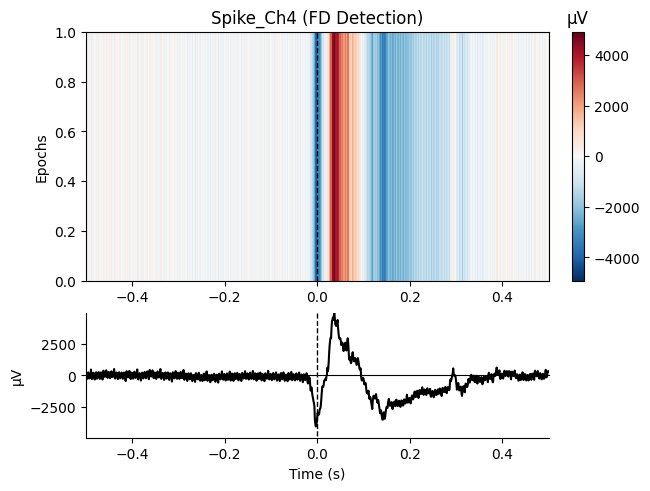

Not setting metadata


2 matching events found


No baseline correction applied


0 projection items activated


Loading data for 2 events and 1001 original time points ...


...

2 matching events found


No baseline correction applied


0 projection items activated


combining channels using "mean"


/home/runner/work/neurodent/neurodent/src/neurodent/results/frequency_domain_results.py:501: RuntimeWarning: Only one channel in group "eeg"; cannot combine by method "mean".
  fig = epochs.plot_image(
/home/runner/work/neurodent/neurodent/src/neurodent/results/frequency_domain_results.py:501: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  fig = epochs.plot_image(


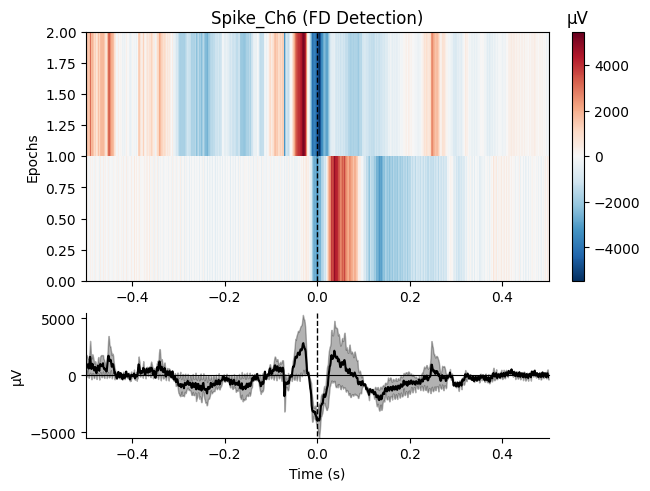

Not setting metadata


2 matching events found


No baseline correction applied


0 projection items activated


Loading data for 2 events and 1001 original time points ...


...

2 matching events found


No baseline correction applied


0 projection items activated


combining channels using "mean"


/home/runner/work/neurodent/neurodent/src/neurodent/results/frequency_domain_results.py:501: RuntimeWarning: Only one channel in group "eeg"; cannot combine by method "mean".
  fig = epochs.plot_image(
/home/runner/work/neurodent/neurodent/src/neurodent/results/frequency_domain_results.py:501: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  fig = epochs.plot_image(


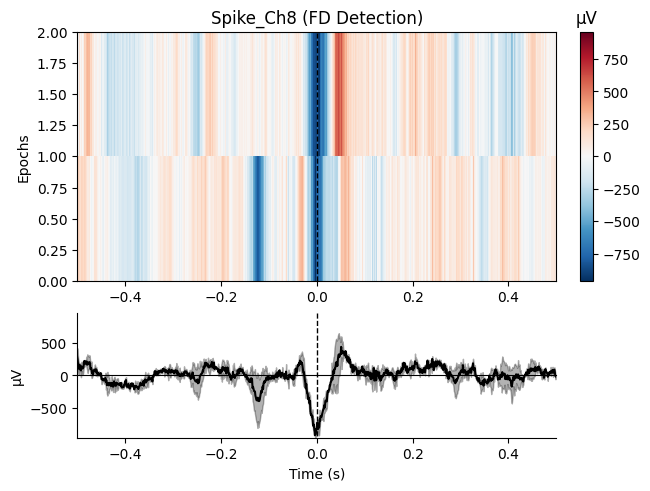

Not setting metadata


1 matching events found


No baseline correction applied


0 projection items activated


Loading data for 1 events and 1001 original time points ...


...

1 matching events found


No baseline correction applied


0 projection items activated


combining channels using "mean"


/home/runner/work/neurodent/neurodent/src/neurodent/results/frequency_domain_results.py:501: RuntimeWarning: Only one channel in group "eeg"; cannot combine by method "mean".
  fig = epochs.plot_image(
/home/runner/work/neurodent/neurodent/src/neurodent/results/frequency_domain_results.py:501: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  fig = epochs.plot_image(


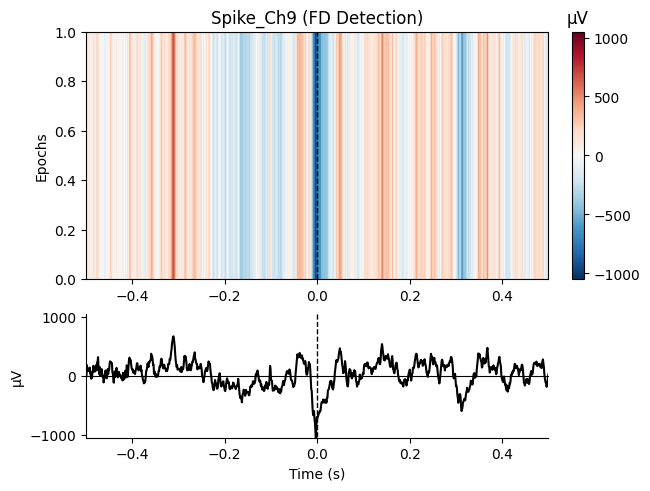

Spikes averaged per channel: {0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 0, 6: 2, 7: 0, 8: 2, 9: 1}


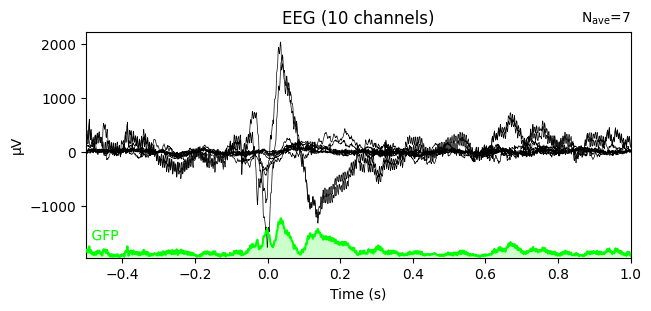

In [9]:
# NeuRodent's built-in spike-triggered average, one figure per channel with spikes
counts = fdsar_loaded.plot_spike_averaged_traces(
    tmin=-0.5,
    tmax=0.5,
    save_dir=None,      # None -> show inline instead of saving
    save_epoch=False,
)
print(f"Spikes averaged per channel: {counts}")

# The same thing via MNE, averaging across all channels and spike events
evoked = epochs.average()
evoked.plot(gfp=True)
plt.show()

## 8. Time-Frequency Analysis

Analyze oscillations around spike times:

Applying baseline correction (mode: percent)


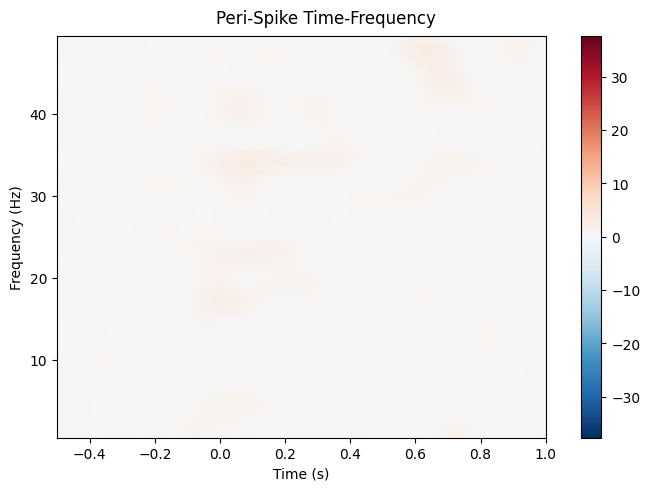

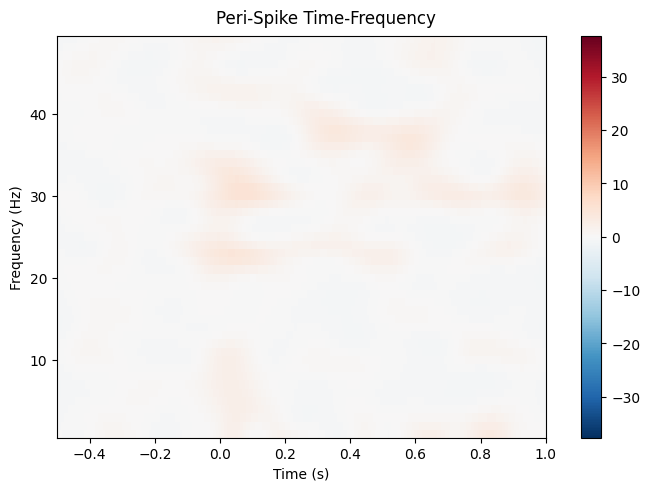

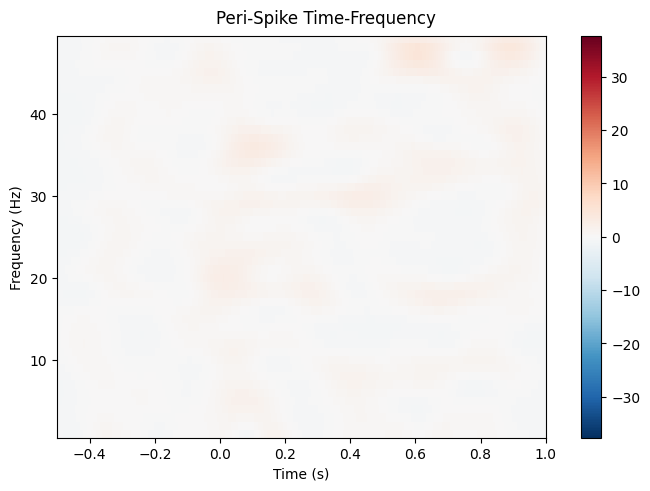

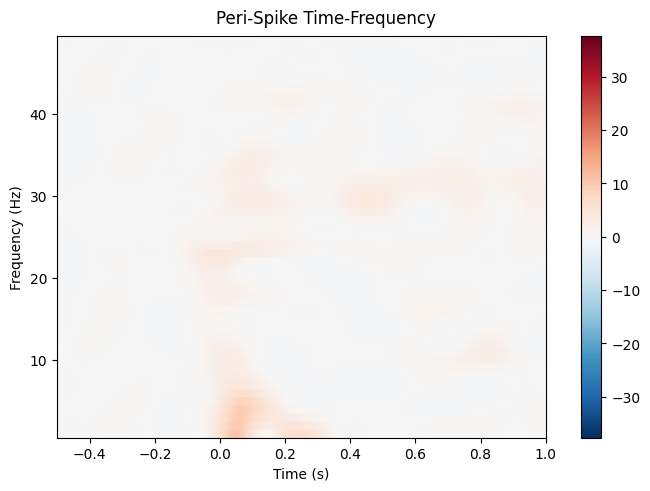

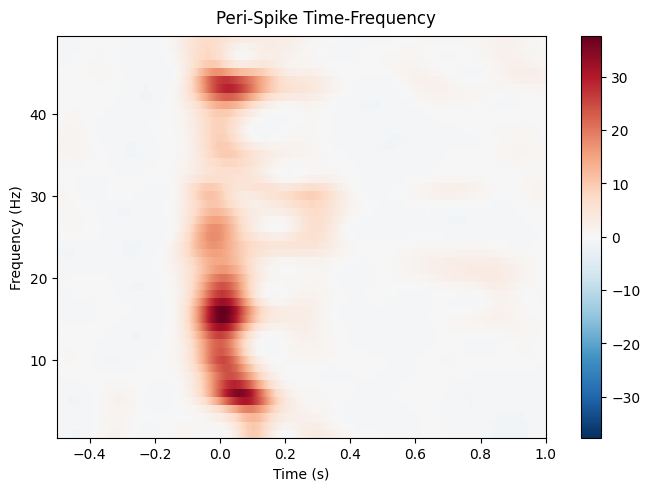

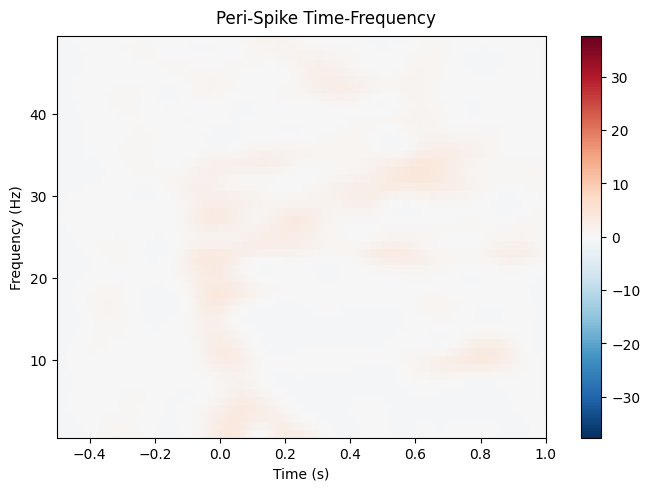

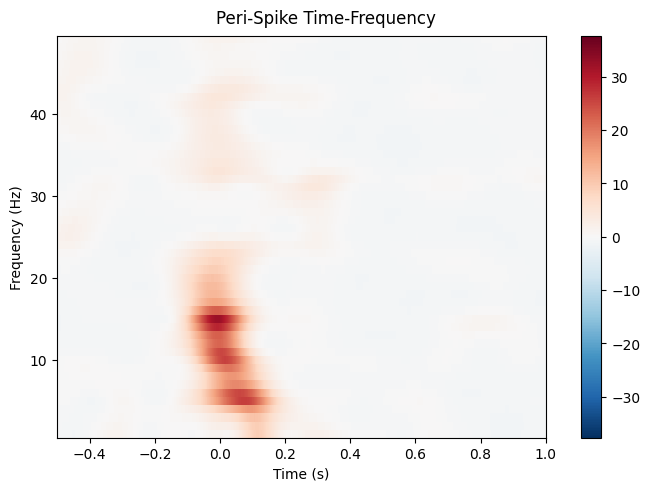

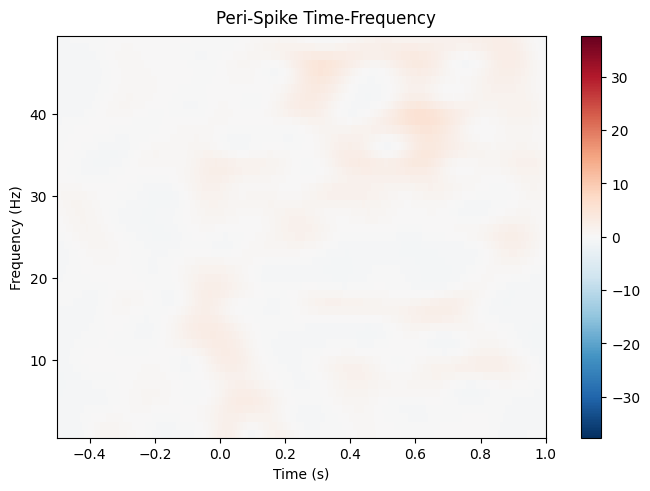

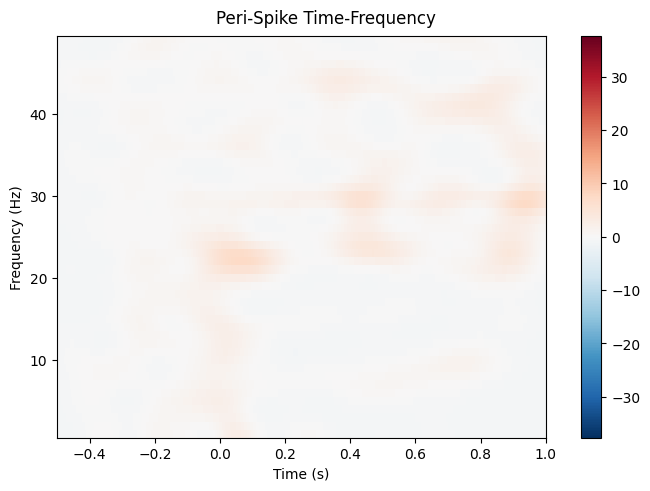

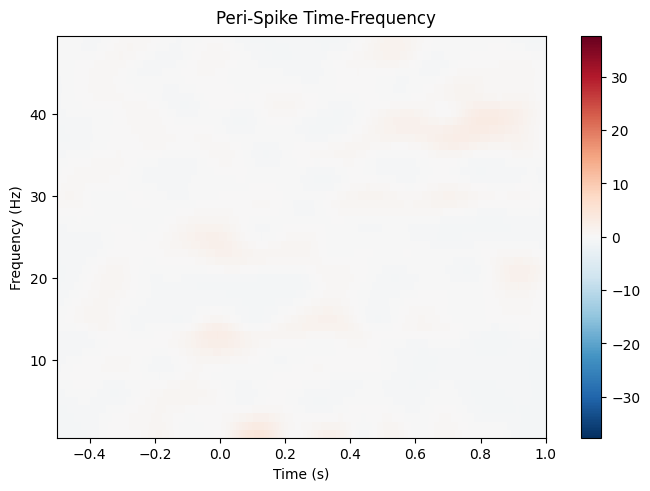

In [10]:
# Compute time-frequency representation
freqs = np.arange(1, 50, 1)  # 1-50 Hz
n_cycles = freqs / 2  # Number of cycles increases with frequency

# Compute TFR using Morlet wavelets
power = epochs.compute_tfr(
    method='morlet',
    freqs=freqs,
    n_cycles=n_cycles,
    use_fft=True,
    average=True
)

# Plot TFR
power.plot(
    picks='eeg',
    baseline=(-0.5, -0.1),
    mode='percent',
    title="Peri-Spike Time-Frequency"
)
plt.show()

## 9. Spike-LFP Phase Locking

Analyze phase relationships between spikes and LFP oscillations:

Setting up band-pass filter from 4 - 8 Hz
IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 8.00 Hz: -6.02, -6.02 dB


IIR filter parameters


---------------------


Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:


- Filter order 16 (effective, after forward-backward)


- Cutoffs at 4.00, 8.00 Hz: -6.02, -6.02 dB


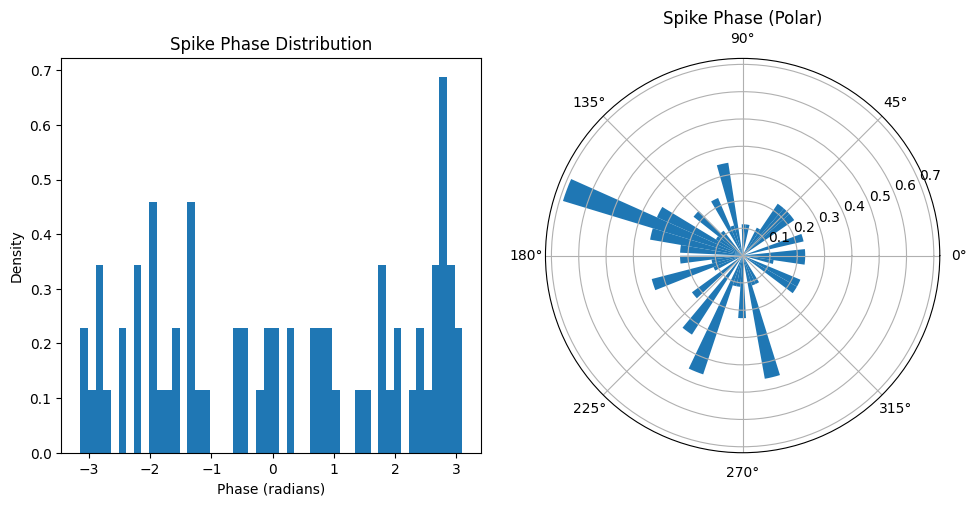

In [11]:
# Filter for specific frequency band (e.g., theta: 4-8 Hz)
epochs_filtered = epochs.copy().filter(
    l_freq=4,
    h_freq=8,
    method='iir'
)

# Apply Hilbert transform to get instantaneous phase
epochs_hilbert = epochs_filtered.apply_hilbert()

# Extract phase at spike time (t=0)
spike_phases = np.angle(epochs_hilbert.get_data()[:, :, epochs.time_as_index(0)[0]])

# Plot phase distribution
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(spike_phases.flatten(), bins=50, density=True)
plt.xlabel("Phase (radians)")
plt.ylabel("Density")
plt.title("Spike Phase Distribution")

# Polar plot
plt.subplot(1, 2, 2, projection='polar')
plt.hist(spike_phases.flatten(), bins=50, density=True)
plt.title("Spike Phase (Polar)")
plt.tight_layout()
plt.show()

## 10. Integrating with WAR

Spike counts become an ordinary WAR feature via `read_sars_spikes`, which bins each
session's spike times into the WAR's existing time windows and fills in `nspike` and
`lognspike`.

Asking `compute_windowed_analysis` for `nspike` on its own does **not** do this (it will return an all-NaN placeholder). The counts only arrive through `read_sars_spikes`.

Note that `read_sars_spikes` must run on an unfiltered WAR, since dropping rows first shifts the window edges and misassigns counts.

INFO:root:Computing windowed analysis for Cage 3 F22-0_ColMajor.bin...
Processing rows: 100%|██████████| 12/12 [00:00<00:00, 211.63it/s]

INFO:root:Added LOF scores for F22 KO Dec-12-2023: 10 channels
INFO:root:Total LOF scores collected: 1 animal days
INFO:root:Channel names: 	['D-009', 'D-010', 'D-012', 'D-014', 'D-015', 'D-016', 'D-017', 'D-019', 'D-021', 'D-022']
INFO:root:Channel abbreviations: 	['LAud', 'LVis', 'LHip', 'LBar', 'LMot', 'RMot', 'RBar', 'RHip', 'RVis', 'RAud']
/home/runner/work/neurodent/neurodent/src/neurodent/results/war_spikes.py:166: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spike_counts = grouped.apply(


Processing rows:   0%|          | 0/12 [00:00<?, ?it/s]

Processing rows: 100%|██████████| 12/12 [00:00<00:00, 211.63it/s]


INFO:root:Added LOF scores for F22 KO Dec-12-2023: 10 channels


INFO:root:Total LOF scores collected: 1 animal days


INFO:root:Channel names: 	['D-009', 'D-010', 'D-012', 'D-014', 'D-015', 'D-016', 'D-017', 'D-019', 'D-021', 'D-022']


INFO:root:Channel abbreviations: 	['LAud', 'LVis', 'LHip', 'LBar', 'LMot', 'RMot', 'RBar', 'RHip', 'RVis', 'RAud']


Windows: 12
Spike counts in the first window: [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
Total binned spikes: 7


/home/runner/work/neurodent/neurodent/src/neurodent/results/war_spikes.py:166: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spike_counts = grouped.apply(


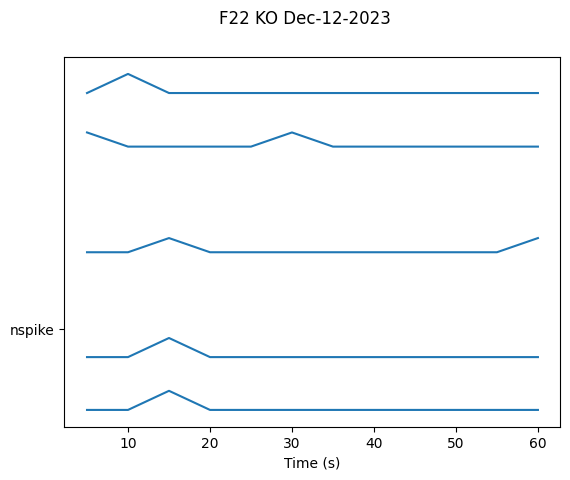

In [12]:
# Compute the windowed analysis, then fold in the detected spikes
war = analyzer.compute_windowed_analysis(
    features=['rms', 'psdband'],
    multiprocess_mode='serial'
)
war = war.read_sars_spikes(fdsars, read_mode='sa', inplace=True)

# nspike holds one count per channel for each time window
result = war.get_result(['nspike'])
print(f"Windows: {len(result)}")
print(f"Spike counts in the first window: {result['nspike'].iloc[0]}")
print(f"Total binned spikes: {np.nansum(np.stack(result['nspike'].to_numpy())):.0f}")

# Plot spike counts over time
ap = AnimalPlotter(war)
ap.plot_linear_temporal(features=['nspike'])

## Next Steps

- **[Visualization Tutorial](visualization.ipynb)**: Advanced plotting for spike data
- **[Windowed Analysis Tutorial](windowed_analysis.ipynb)**: Combine spike counts with other features